# A gauge-invariant clustering coefficient for complex-weighted bipartite networks

Computations for Theorem 11, Corollary 12 and Lemma A.1, and the checks reported in Appendix C.3.

## Setup

In [ ]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260922)

## Ensemble

In [ ]:
def ring_lattice(nU, nV, k):
    A = np.zeros((nU, nV), dtype=np.int8)
    for u in range(nU):
        for j in range(k):
            A[u, (u + j) % nV] = 1
    return A


def rewire(A, p, rng):
    A = A.copy()
    for u in range(A.shape[0]):
        nbrs = np.flatnonzero(A[u])
        sel = nbrs[rng.random(nbrs.size) < p]
        if sel.size == 0:
            continue
        A[u, sel] = 0
        non = np.flatnonzero(A[u] == 0)
        non = non[~np.isin(non, sel)]
        A[u, rng.choice(non, size=sel.size, replace=False)] = 1
    return A


def random_phases(A, delta, R, rng):
    return A[None].astype(float) * np.exp(1j * rng.uniform(-delta, delta, size=(R,) + A.shape))

## Phase factor $Q_u$, Eq. (5) via Proposition 8

In [ ]:
def phase_factor(Bs, A):
    N = (A @ A.T).astype(float)
    np.fill_diagonal(N, 0.0)
    m = (N * (N - 1)).sum(1)
    M2 = np.abs(Bs @ np.conj(np.swapaxes(Bs, 1, 2))) ** 2
    idx = np.arange(A.shape[0])
    M2[:, idx, idx] = 0.0
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(m > 0, (M2.sum(2) - N.sum(1)[None]) / m, np.nan)

## Second moments, Eq. (19)

$\sigma^2=\tfrac12(1+|\chi(2)|^4)-r^4$, $\ \kappa_1=\tfrac12 r^2(1+|\chi(2)|^2)-r^4$,
$\ \kappa_2=\tfrac12 r^3(1+\chi(2))-r^4$, with $r=|\chi(1)|^2$ and $\chi(t)=\sin(t\Delta)/(t\Delta)$.

In [ ]:
def moments(delta):
    c1 = np.sinc(np.asarray(delta) / np.pi)
    c2 = np.sinc(2 * np.asarray(delta) / np.pi)
    r = c1 ** 2
    return (0.5 * (1 + c2 ** 4) - r ** 4,
            0.5 * r ** 2 * (1 + c2 ** 2) - r ** 4,
            0.5 * r ** 3 * (1 + c2) - r ** 4)

## Counts of overlapping pairs of squares

`mt` $=\tilde m_u$, `P1` $=P^{(1)}_u$ (pairs sharing a phase difference), `P2` $=P^{(2)}_u$
(pairs sharing a single link).

In [ ]:
def square_pair_counts(A):
    A = A.astype(np.int64)
    N = A @ A.T
    K = A.T @ A
    ku, kv = A.sum(1), A.sum(0)
    NA = N @ A
    Nd = N.copy()
    np.fill_diagonal(Nd, 0)
    mt = (Nd * (Nd - 1) // 2).sum(1)
    PA = (Nd * (Nd - 1) * (Nd - 2) // 2).sum(1)
    PB = np.zeros(A.shape[0], np.int64)
    P2 = np.zeros(A.shape[0], np.int64)
    for u in range(A.shape[0]):
        nb = np.flatnonzero(A[u])
        c = K[np.ix_(nb, nb)] - 1
        cc = c[np.triu_indices(nb.size, 1)]
        PB[u] = (cc * (cc - 1) // 2).sum()
        n_v = NA[u, nb] - ku[u] - kv[nb] + 1
        P2[u] = (n_v * (n_v - 1) // 2).sum() - PA[u] - 2 * PB[u]
    return dict(mt=mt, PA=PA, PB=PB, P1=PA + PB, P2=P2)


def square_pair_counts_bruteforce(A, u):
    nb_u = set(np.flatnonzero(A[u]))
    sq = [(up, v1, v2)
          for up in range(A.shape[0]) if up != u
          for v1, v2 in itertools.combinations(sorted(nb_u & set(np.flatnonzero(A[up]))), 2)]
    PA = PB = P2 = 0
    for (a, v1, v2), (b, w1, w2) in itertools.combinations(sq, 2):
        common = len({v1, v2} & {w1, w2})
        if a == b:
            PA += common == 1
        elif common == 2:
            PB += 1
        elif common == 1:
            P2 += 1
    return dict(mt=len(sq), PA=PA, PB=PB, P1=PA + PB, P2=P2)


def ring_counts(k):
    mt = k * (k - 1) * (k - 2) // 3
    PA = k * (k - 1) * (k - 2) * (k - 3) // 4
    P2 = k * (k - 1) * (k - 2) * (27 * k * k - 139 * k + 194) // 120
    return {key: np.array([val]) for key, val in
            dict(mt=mt, PA=PA, PB=PA // 2, P1=PA + PA // 2, P2=P2).items()}

## Variance of $Q_u$, Eq. (18), and the independence estimate $2\sigma^2/m_u$

In [ ]:
def var_Q(counts, delta, with_kappa2=True):
    s2, k1, k2 = moments(delta)
    mt = counts["mt"].astype(float)
    num = mt * s2 + 2 * counts["P1"] * k1 + (2 * counts["P2"] * k2 if with_kappa2 else 0.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        return num / mt ** 2


def var_Q_independent(counts, delta):
    with np.errstate(invalid="ignore", divide="ignore"):
        return moments(delta)[0] / counts["mt"].astype(float)


def sample_var(A, delta, R, rng, batch=250):
    Q = np.concatenate([phase_factor(random_phases(A, delta, batch, rng), A)
                        for _ in range(R // batch)])
    return Q.var(axis=0, ddof=1)

## Check 1: the covariances of Lemma A.1

In [ ]:
S = 4_000_000
print(f"{'Delta':>7} {'case':>6} {'sampled':>10} {'Eq. (19)':>10}")
for name, d in [("pi/4", np.pi / 4), ("pi/2", np.pi / 2), ("2", 2.0), ("pi", np.pi)]:
    _, k1, k2 = moments(d)
    x = rng.uniform(-d, d, size=(7, S))
    cA = np.cov(np.cos(x[0] - x[1] + x[2] - x[3]), np.cos(x[0] - x[1] + x[4] - x[5]))[0, 1]
    cB = np.cov(np.cos(x[0] - x[2] + x[3] - x[1]), np.cos(x[0] - x[4] + x[5] - x[1]))[0, 1]
    cC = np.cov(np.cos(x[0] - x[1] + x[2] - x[3]), np.cos(x[0] - x[4] + x[5] - x[6]))[0, 1]
    for case, c, th in (("a-i", cA, k1), ("a-ii", cB, k1), ("b", cC, k2)):
        print(f"{name:>7} {case:>6} {c:10.5f} {th:10.5f}")

  Delta   case    sampled   Eq. (19)


   pi/4    a-i    0.02991    0.02997
   pi/4   a-ii    0.02974    0.02997
   pi/4      b    0.00415    0.00412


   pi/2    a-i    0.05512    0.05515
   pi/2   a-ii    0.05516    0.05515
   pi/2      b    0.00639    0.00631


      2    a-i    0.01982    0.02030
      2   a-ii    0.01997    0.02030
      2      b    0.00227    0.00175


     pi    a-i   -0.00016    0.00000
     pi   a-ii   -0.00033    0.00000
     pi      b    0.00016    0.00000


## Check 2: the counts against direct enumeration

In [ ]:
bad = 0
for k in range(3, 16):
    A = ring_lattice(60, 60, k)
    fast, closed = square_pair_counts(A), ring_counts(k)
    bad += any((fast[key] != closed[key][0]).any() for key in closed)
    bad += any(square_pair_counts_bruteforce(A, 0)[key] != fast[key][0] for key in fast)
for p in (0.1, 0.5, 1.0):
    A = rewire(ring_lattice(50, 50, 6), p, rng)
    for M in (A, A.T.copy()):
        fast = square_pair_counts(M)
        for u in range(0, 50, 7):
            bad += any(square_pair_counts_bruteforce(M, u)[key] != fast[key][u] for key in fast)
print("mismatches:", bad)

mismatches: 0


## Check 3: the regular lattice, Corollary 12

In [ ]:
DEG = (3, 4, 6, 10, 14)
DELTAS = np.sort(np.array([0.2, 0.5, np.pi / 4, 1.0, np.pi / 2, 2.0, 2.4, 3 * np.pi / 4, 2.9, np.pi]))
lattice = {}
for k in DEG:
    A = ring_lattice(150, 150, k)
    lattice[k] = np.array([np.sqrt(sample_var(A, d, 500, rng).mean()) for d in DELTAS])

print(f"{'k':>3} {'m_u':>5} {'Delta':>7} {'measured':>9} {'Cor. 12':>9} {'indep.':>9}")
dev, ratio = [], []
for k in DEG:
    cnt = ring_counts(k)
    for d, sd in zip(DELTAS, lattice[k]):
        ex = np.sqrt(var_Q(cnt, d)[0])
        ind = np.sqrt(var_Q_independent(cnt, d)[0])
        dev.append(abs(sd / ex - 1))
        ratio.append(sd / ind)
        print(f"{k:>3} {2*cnt['mt'][0]:>5} {d:7.3f} {sd:9.4f} {ex:9.4f} {ind:9.4f}")
print(f"\nmax |measured / Cor. 12 - 1| = {max(dev):.2%}")
print(f"max  measured / independence  = {max(ratio):.2f}")

  k   m_u   Delta  measured   Cor. 12    indep.
  3     4   0.200    0.0243    0.0244    0.0241
  3     4   0.500    0.1375    0.1364    0.1345
  3     4   0.785    0.2765    0.2780    0.2743
  3     4   1.000    0.3726    0.3720    0.3674
  3     4   1.571    0.4880    0.4896    0.4863
  3     4   2.000    0.5003    0.5003    0.4994
  3     4   2.356    0.5002    0.5006    0.5005
  3     4   2.400    0.4989    0.5005    0.5004
  3     4   2.900    0.5011    0.5000    0.5000
  3     4   3.142    0.4989    0.5000    0.5000
  4    16   0.200    0.0149    0.0151    0.0120
  4    16   0.500    0.0845    0.0840    0.0672
  4    16   0.785    0.1718    0.1704    0.1371
  4    16   1.000    0.2267    0.2261    0.1837
  4    16   1.571    0.2788    0.2782    0.2432
  4    16   2.000    0.2627    0.2624    0.2497
  4    16   2.356    0.2525    0.2528    0.2502
  4    16   2.400    0.2508    0.2522    0.2502
  4    16   2.900    0.2493    0.2500    0.2500
  4    16   3.142    0.2500    0.2500   

## Check 4: node by node on fixed rewired topologies

In [ ]:
print(f"{'p':>4} {'Delta':>7} {'nodes':>6} {'median |meas/Eq.18-1|':>22} {'median |meas/indep-1|':>22}")
for p in (0.1, 1.0):
    A = rewire(ring_lattice(100, 100, 6), p, rng)
    for d in (np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi):
        re, ro, n = [], [], 0
        for M in (A, A.T.copy()):
            cnt = square_pair_counts(M)
            ok = cnt["mt"] >= 1
            v = sample_var(M, d, 4000, rng)
            re += list(np.abs(v[ok] / var_Q(cnt, d)[ok] - 1))
            ro += list(np.abs(v[ok] / var_Q_independent(cnt, d)[ok] - 1))
            n += int(ok.sum())
        print(f"{p:>4} {d:7.3f} {n:>6} {np.median(re):>22.3f} {np.median(ro):>22.3f}")
print("\nsampling floor of a variance from 4000 draws: sqrt(2/4000) = 2.2%")

   p   Delta  nodes  median |meas/Eq.18-1|  median |meas/indep-1|


 0.1   0.785    200                  0.016                  1.432


 0.1   1.571    200                  0.014                  0.798


 0.1   2.356    200                  0.012                  0.050


 0.1   3.142    200                  0.016                  0.016


 1.0   0.785    184                  0.021                  0.074


 1.0   1.571    184                  0.012                  0.036


 1.0   2.356    184                  0.013                  0.014


 1.0   3.142    184                  0.013                  0.013

sampling floor of a variance from 4000 draws: sqrt(2/4000) = 2.2%


## Figure 6

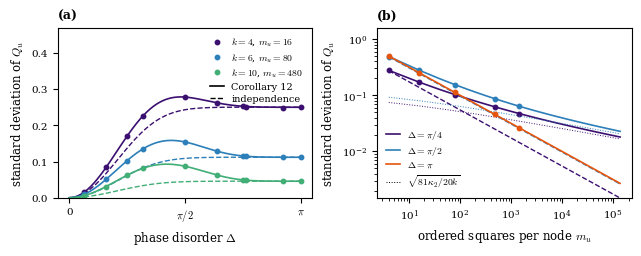

In [ ]:
plt.rcParams.update({"font.size": 8.5, "axes.labelsize": 8.5, "legend.fontsize": 7,
                     "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
                     "font.family": "serif", "mathtext.fontset": "cm"})
fig, ax = plt.subplots(1, 2, figsize=(6.3, 2.45), constrained_layout=True)
cols = {4: "#3b0f70", 6: "#2c7fb8", 10: "#41ae76"}

dd = np.linspace(1e-3, np.pi, 300)
for k, c in cols.items():
    cnt = ring_counts(k)
    ax[0].plot(dd, np.sqrt([var_Q(cnt, x)[0] for x in dd]), color=c, lw=1.2)
    ax[0].plot(dd, np.sqrt([var_Q_independent(cnt, x)[0] for x in dd]), color=c, lw=1.0, ls="--")
    ax[0].plot(DELTAS, lattice[k], "o", ms=3.2, color=c,
               label=rf"$k={k}$, $m_u={2*cnt['mt'][0]}$")
ax[0].plot([], [], "k-", lw=1.2, label="Corollary 12")
ax[0].plot([], [], "k--", lw=1.0, label="independence")
ax[0].set_xticks([0, np.pi / 2, np.pi])
ax[0].set_xticklabels(["0", r"$\pi/2$", r"$\pi$"])
ax[0].set_xlabel(r"phase disorder $\Delta$")
ax[0].set_ylabel(r"standard deviation of $Q_u$")
ax[0].set_ylim(0, 0.47)
ax[0].legend(frameon=False, loc="upper right", handlelength=1.4, labelspacing=0.3)
ax[0].set_title("(a)", loc="left", fontweight="bold", fontsize=9)

ks = np.arange(3, 61)
ms = 2 * ks * (ks - 1) * (ks - 2) / 3
for d, lab, c in ((np.pi / 4, r"$\Delta=\pi/4$", "#3b0f70"),
                  (np.pi / 2, r"$\Delta=\pi/2$", "#2c7fb8"),
                  (np.pi, r"$\Delta=\pi$", "#e6550d")):
    ax[1].loglog(ms, [np.sqrt(var_Q(ring_counts(k), d)[0]) for k in ks], color=c, lw=1.2, label=lab)
    if d < np.pi:
        ax[1].loglog(ms, [np.sqrt(var_Q_independent(ring_counts(k), d)[0]) for k in ks],
                     color=c, lw=1.0, ls="--")
        ax[1].loglog(ms, np.sqrt(81 * moments(d)[2] / (20 * ks)), color=c, lw=0.7, ls=":")
    j = int(np.argmin(np.abs(DELTAS - d)))
    ax[1].loglog([2 * ring_counts(k)["mt"][0] for k in DEG], [lattice[k][j] for k in DEG],
                 "o", ms=3.2, color=c)
ax[1].set_xlabel(r"ordered squares per node $m_u$")
ax[1].set_ylabel(r"standard deviation of $Q_u$")
ax[1].set_ylim(1.5e-3, 1.6)
ax[1].legend(handles=[plt.Line2D([], [], color=c, lw=1.2, label=l)
                      for c, l in (("#3b0f70", r"$\Delta=\pi/4$"),
                                   ("#2c7fb8", r"$\Delta=\pi/2$"),
                                   ("#e6550d", r"$\Delta=\pi$"))]
                     + [plt.Line2D([], [], color="k", lw=0.7, ls=":",
                                   label=r"$\sqrt{81\kappa_2/20k}$")],
             frameon=False, loc="lower left", labelspacing=0.3, handlelength=1.4)
ax[1].set_title("(b)", loc="left", fontweight="bold", fontsize=9)

fig.savefig("figure6_resolution.pdf")
fig.savefig("figure6_resolution.png", dpi=220)